# 16. 변화점(Changepoint) Feature 실험 (Phase 12 — 로드맵 D)

**목적**: 14번 A 추세(early/late 고정 절반 차이)를 한 단계 정교화. 15구 내 구속·회전수 시계열에서 **실제로 꺾이는 분할점(change point)** 을 데이터가 찾게 해, 그 위치·크기·존재여부를 feature로 추가했을 때 예측력이 오르는지 paired t-test로 검증한다.

**추가된 feature (6개, `feature_aggregator._aggregate_changepoint_features`에서 자동 생성)**

| metric | feature | 의미 |
|---|---|---|
| speed | `cp_speed_detected` / `cp_speed_pos` / `cp_speed_drop` | 구속 변화점 존재/위치(0~1)/전후 평균차 |
| spin  | `cp_spin_detected` / `cp_spin_pos` / `cp_spin_drop` | 회전수 변화점 존재/위치/전후 평균차 |

**실험 설계 (14번과 동일 틀)**

| 실험 | 내용 | 비교 |
|---|---|---|
| E10-1 | 기존 feature만 (CP 제외) | 기준 |
| E10-2 | + CP(변화점) 전체 | E10-1 vs E10-2 |
| 🔬 E10-3 | E10-1 vs E10-2 **paired t-test** (n=30 seeds) | CP feature 기여도 검증 |
| E10-4 | SHAP으로 CP feature 순위 확인 | trend/delta보다 위로 올라오는지 |

> ⚠ **실행 전 필수**: `feature_aggregator.py`가 최신본(`_aggregate_changepoint_features` 포함)이어야 함. 위에서 아래로 Run All.

<!-- CONCLUSION-CELL -->
> ## ❌ 결론 — 변화점(Changepoint) Feature: **기각 (효과 없음)**
>
> 15구 내 구속·회전수 시계열의 실제 꺾이는 분할점(cp_*, 6개)을 feature로 추가.
>
> | 단계 | features | val R² |
> |---|---|---|
> | E10-1 base | 67 | 0.0861 |
> | E10-2 +CP(변화점) | 73 | 0.0860 |
>
> - **30 seed paired t-test: 차이 -0.0001, t=-0.39, p=0.70 → 무의** ❌
> - SHAP: `cp_spin_drop`이 8위까지 올랐으나 그 feature 넣어도 성능 개선 없음 → **중요도≠기여** 재확인.
> - 14번(A추세·B변동성) → 15번(1D-CNN) → 16번(changepoint)까지 **"투구 순서/시계열 정보를 정교화"하려는 시도는 전부 기각.** 15구 평균(정적 aggregate)이 이미 신호를 다 담음.
> - 로드맵 D 종결. 정형 최종 모델은 여전히 [13_final_evaluation] 채택본.

In [1]:
# ── 환경 감지 ─────────────────────────
import os, sys

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/투수 컨디션 예측 ML'
    NB_DIR = os.path.join(DRIVE, '3_modeling')
    sys.path.insert(0, NB_DIR)
else:
    DRIVE  = os.path.dirname(os.path.abspath('__file__'))
    NB_DIR = os.path.dirname(os.path.abspath('__file__'))

INTERIM_DIR = os.path.join(DRIVE, '0_data', '2_interim')
FEATURE_DIR = os.path.join(DRIVE, '0_data', '4_features')
OUTPUT_DIR  = os.path.join(DRIVE, '4_output')
STARTERS    = os.path.join(INTERIM_DIR, 'starters_all.parquet')
LOOKUP      = os.path.join(INTERIM_DIR, 'prev_season_lookup.parquet')
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODE, N = 'pitch', 15   # X구간 고정: pitch15
print(f'환경: {"코랩" if IN_COLAB else "로컬"}  |  X구간: {MODE}{N}')

Mounted at /content/drive
환경: 코랩  |  X구간: pitch15


In [2]:
# ── 패키지 + 최적 파라미터 ────────────────
try:
    import duckdb, xgboost, shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'duckdb', 'xgboost', 'shap', '-q'])

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import xgboost as xgb
import shap
from sklearn.metrics import mean_squared_error, r2_score
import importlib
import feature_aggregator
importlib.reload(feature_aggregator)
from feature_aggregator import build_features

# Phase 7 튜닝 최적 파라미터 로드 — 없으면 기본값
BP_PATH = os.path.join(OUTPUT_DIR, 'best_params.json')
if os.path.exists(BP_PATH):
    XGB_PARAMS = json.load(open(BP_PATH, encoding='utf-8'))['XGB']
    print('best_params.json 로드:', XGB_PARAMS)
else:
    XGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8)
    print('best_params.json 없음 → 기본 파라미터 사용')

XGB_FIXED = dict(random_state=42, n_jobs=-1, verbosity=0, early_stopping_rounds=50)
print('패키지 로드 완료')

best_params.json 로드: {'n_estimators': 741, 'learning_rate': 0.014691495151176124, 'max_depth': 6, 'subsample': 0.8246054423397551, 'colsample_bytree': 0.6170762731121904, 'min_child_weight': 1, 'reg_alpha': 0.6213478443574787, 'reg_lambda': 0.9941387943895944}
패키지 로드 완료


## 1. Feature 빌드 + CP 컬럼 식별

`build_features`를 한 번 호출해 전체 feature를 만든 뒤, 이름 규칙(`cp_`)으로 변화점 컬럼을 자동 분류한다.

In [3]:
df = build_features(STARTERS, LOOKUP, MODE, N, include_delta=True)
print(f'전체: {len(df):,}행  |  컬럼 {len(df.columns)}개')

META_COLS = ['game_pk', 'pitcher', 'season', 'y_whiff', 'swings']
ALL_FEATS = [c for c in df.columns if c not in META_COLS]

# CP(변화점) 컬럼 자동 식별
CP_COLS = [c for c in ALL_FEATS if c.startswith('cp_')]
BASE_COLS = [c for c in ALL_FEATS if c not in CP_COLS]

assert CP_COLS, 'CP(cp_*) 컬럼이 없음 → feature_aggregator.py가 구버전입니다. 최신본으로 교체 후 재실행.'

print(f'\nBASE feature ({len(BASE_COLS)}개)')
print(f'CP 변화점 ({len(CP_COLS)}개): {CP_COLS}')

# CP feature 탐지율 간단 요약 (detected 비율)
for m in ['speed', 'spin']:
    col = f'cp_{m}_detected'
    if col in df.columns:
        rate = df[col].mean()
        print(f'  {col} 탐지율: {rate:.1%}  (drop 평균 {df[f"cp_{m}_drop"].mean():+.3f})')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

전체: 23,225행  |  컬럼 77개

BASE feature (67개)
CP 변화점 (6개): ['cp_speed_detected', 'cp_speed_pos', 'cp_speed_drop', 'cp_spin_detected', 'cp_spin_pos', 'cp_spin_drop']
  cp_speed_detected 탐지율: 100.0%  (drop 평균 -2.245)
  cp_spin_detected 탐지율: 100.0%  (drop 평균 +9.752)


In [4]:
# 시즌 기반 split (train 2021~2023 / val 2024 / test 2025)
train = df[df['season'].isin([2021, 2022, 2023])].copy()
val   = df[df['season'] == 2024].copy()
test  = df[df['season'] == 2025].copy()
print(f'train {len(train):,} | val {len(val):,} | test {len(test):,}')

def fit_eval(feat_cols, seed=42):
    """주어진 feature set으로 XGB 학습 → (val_r2, val_rmse, test_r2, model) 반환."""
    p = {**XGB_PARAMS, **XGB_FIXED, 'random_state': seed}
    m = xgb.XGBRegressor(**p)
    m.fit(train[feat_cols], train['y_whiff'],
          eval_set=[(val[feat_cols], val['y_whiff'])], verbose=False)
    vr2  = r2_score(val['y_whiff'], m.predict(val[feat_cols]))
    vrmse = mean_squared_error(val['y_whiff'], m.predict(val[feat_cols])) ** 0.5
    tr2  = r2_score(test['y_whiff'], m.predict(test[feat_cols])) if len(test) else float('nan')
    return vr2, vrmse, tr2, m

train 13,871 | val 4,668 | test 4,686


## 2. E10-1 ~ E10-2 단계적 추가 비교

In [5]:
experiments = {
    'E10-1 base':        BASE_COLS,
    'E10-2 +CP(변화점)':  BASE_COLS + CP_COLS,
}

rows = []
for name, cols in experiments.items():
    vr2, vrmse, tr2, _ = fit_eval(cols)
    rows.append(dict(name=name, n_features=len(cols),
                     val_r2=round(vr2, 4), val_rmse=round(vrmse, 4),
                     test_r2=round(tr2, 4)))
    print(f'{name:20s} feat={len(cols):3d}  val_R²={vr2:.4f}  val_RMSE={vrmse:.4f}  test_R²={tr2:.4f}')

result_table = pd.DataFrame(rows)
result_table

E10-1 base           feat= 67  val_R²=0.0863  val_RMSE=0.0849  test_R²=0.0361
E10-2 +CP(변화점)       feat= 73  val_R²=0.0854  val_RMSE=0.0849  test_R²=0.0298


,name,n_features,val_r2,val_rmse,test_r2
0,E10-1 base,67,0.0863,0.0849,0.0361
1,E10-2 +CP(변화점),73,0.0854,0.0849,0.0298


## 3. 🔬 E10-3 Paired t-test — 기존(E10-1) vs +CP(E10-2)

30개 random seed로 반복 학습 → Val R² 쌍으로 paired t-test.

In [6]:
N_SEEDS = 30
r2_base, r2_cp = [], []

for i, seed in enumerate(range(N_SEEDS)):
    r2_base.append(fit_eval(BASE_COLS, seed)[0])
    r2_cp.append(fit_eval(BASE_COLS + CP_COLS, seed)[0])
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_SEEDS} 완료')

r2_base = np.array(r2_base)
r2_cp   = np.array(r2_cp)
diff = r2_cp - r2_base

t_stat, p_value = stats.ttest_rel(r2_cp, r2_base)

print('\n' + '=' * 52)
print('Paired t-test: 변화점(CP) feature 기여도')
print('=' * 52)
print(f'E10-1 base 평균 R²: {r2_base.mean():.4f} ± {r2_base.std():.4f}')
print(f'E10-2 +CP  평균 R²: {r2_cp.mean():.4f} ± {r2_cp.std():.4f}')
print(f'평균 차이 (+CP - base): {diff.mean():+.4f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value    : {p_value:.4f}')
print()
if p_value < 0.05:
    print('→ p < 0.05: 변화점 feature가 통계적으로 유의미한 개선 ✅')
else:
    print('→ p ≥ 0.05: 통계적으로 유의미한 차이 없음 ❌')

  10/30 완료
  20/30 완료
  30/30 완료

Paired t-test: 변화점(CP) feature 기여도
E10-1 base 평균 R²: 0.0861 ± 0.0012
E10-2 +CP  평균 R²: 0.0860 ± 0.0013
평균 차이 (+CP - base): -0.0001
t-statistic: -0.3888
p-value    : 0.7003

→ p ≥ 0.05: 통계적으로 유의미한 차이 없음 ❌


/tmp/ipykernel_2234/99717938.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([r2_base, r2_cp], labels=['E10-1\nbase', 'E10-2\n+CP'], patch_artist=True,
/tmp/ipykernel_2234/99717938.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/99717938.py:20: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/99717938.py:20: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/99717938.py:20: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/99717938.py:20: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

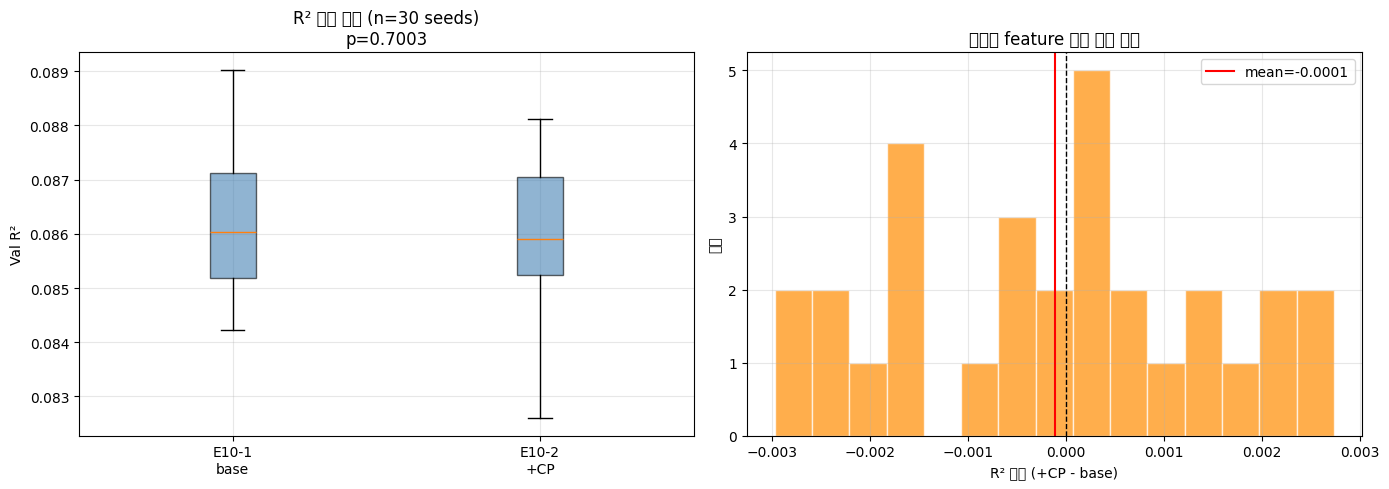

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.boxplot([r2_base, r2_cp], labels=['E10-1\nbase', 'E10-2\n+CP'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Val R²')
ax.set_title(f'R² 분포 비교 (n={N_SEEDS} seeds)\np={p_value:.4f}')
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(diff, bins=15, color='darkorange', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(diff.mean(), color='red', linewidth=1.5, label=f'mean={diff.mean():+.4f}')
ax.set_xlabel('R² 차이 (+CP - base)')
ax.set_ylabel('빈도')
ax.set_title('변화점 feature 기여 차이 분포')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'changepoint_ttest.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. E10-4 SHAP — 변화점 feature 순위 확인

14번 A 추세/B 변동성이 하위권이었던 한계를, 변화점 feature가 극복하는지 확인.

In [8]:
FULL_COLS = BASE_COLS + CP_COLS
_, _, _, model_full = fit_eval(FULL_COLS)

explainer = shap.TreeExplainer(model_full)
shap_vals = explainer(val[FULL_COLS])
shap_mean = pd.Series(np.abs(shap_vals.values).mean(axis=0),
                      index=FULL_COLS).sort_values(ascending=False)
rank = {f: i + 1 for i, f in enumerate(shap_mean.index)}

print(f'전체 {len(FULL_COLS)}개 feature 중 CP feature SHAP 순위:\n')
for f in sorted(CP_COLS, key=lambda x: rank[x]):
    print(f'  {rank[f]:3d}위  {f:24s}  SHAP={shap_mean[f]:.5f}')

print('\n[상위 15개 전체]')
for i, (f, v) in enumerate(shap_mean.head(15).items()):
    tag = '  ← CP feature' if f in CP_COLS else ''
    print(f'  {i+1:3d}위  {f:24s}  {v:.5f}{tag}')

전체 73개 feature 중 CP feature SHAP 순위:

    8위  cp_spin_drop              SHAP=0.00188
   19위  cp_speed_drop             SHAP=0.00099
   59위  cp_spin_pos               SHAP=0.00026
   61위  cp_speed_pos              SHAP=0.00025
   72위  cp_speed_detected         SHAP=0.00000
   73위  cp_spin_detected          SHAP=0.00000

[상위 15개 전체]
    1위  avg_speed_Fastball        0.00851
    2위  avg_spin_Fastball         0.00730
    3위  strike_ratio              0.00278
    4위  prev_spin_Fastball        0.00251
    5위  avg_speed_Breaking        0.00216
    6위  std_pos_z_Fastball        0.00210
    7위  prev_speed_Fastball       0.00208
    8위  cp_spin_drop              0.00188  ← CP feature
    9위  avg_spin_Breaking         0.00184
   10위  fastball_ratio            0.00175
   11위  avg_ext_Fastball          0.00174
   12위  avg_ext                   0.00165
   13위  avg_pos_x_Breaking        0.00158
   14위  avg_arm_angle             0.00141
   15위  prev_pos_z_Fastball       0.00122


/tmp/ipykernel_2234/1739969993.py:8: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/1739969993.py:8: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/1739969993.py:8: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/1739969993.py:8: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/1739969993.py:8: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/1739969993.py:8: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2234/1739969993.py:9: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.savefig(

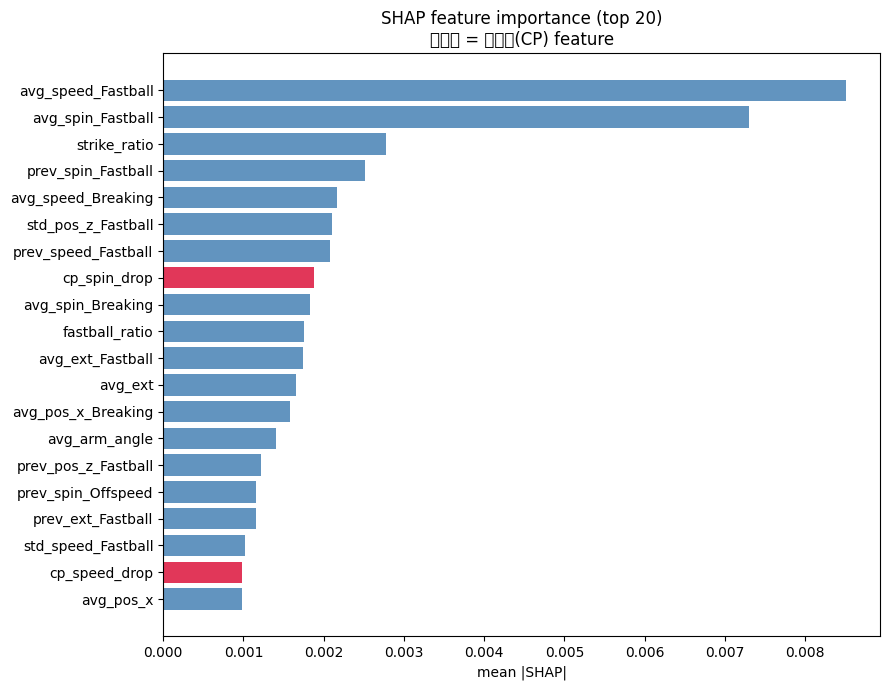

In [9]:
# SHAP bar plot (상위 20개, CP feature 강조)
top = shap_mean.head(20)[::-1]
colors = ['crimson' if f in CP_COLS else 'steelblue' for f in top.index]
plt.figure(figsize=(9, 7))
plt.barh(top.index, top.values, color=colors, alpha=0.85)
plt.xlabel('mean |SHAP|')
plt.title('SHAP feature importance (top 20)\n빨간색 = 변화점(CP) feature')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'changepoint_shap.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. 결과 저장

In [10]:
# 단계표 저장
result_table.to_csv(os.path.join(OUTPUT_DIR, 'changepoint_results.csv'),
                    index=False, encoding='utf-8-sig')

# paired t-test seed별 + 요약 저장
pd.DataFrame({'seed': range(N_SEEDS), 'r2_base': r2_base,
              'r2_cp': r2_cp, 'diff': diff}).to_csv(
    os.path.join(OUTPUT_DIR, 'changepoint_ttest_seeds.csv'),
    index=False, encoding='utf-8-sig')

summary = {
    'E10-1 base mean R²':  round(float(r2_base.mean()), 4),
    'E10-2 cp mean R²':    round(float(r2_cp.mean()), 4),
    'mean diff':           round(float(diff.mean()), 4),
    't_stat':              round(float(t_stat), 4),
    'p_value':             round(float(p_value), 4),
    'significant':         bool(p_value < 0.05),
}
json.dump(summary, open(os.path.join(OUTPUT_DIR, 'changepoint_ttest.json'),
                        'w', encoding='utf-8'), ensure_ascii=False, indent=2)

print('저장 완료:')
print('  4_output/changepoint_results.csv')
print('  4_output/changepoint_ttest_seeds.csv')
print('  4_output/changepoint_ttest.json')
print('  4_output/changepoint_ttest.png')
print('  4_output/changepoint_shap.png')
print('\n요약:', summary)

저장 완료:
  4_output/changepoint_results.csv
  4_output/changepoint_ttest_seeds.csv
  4_output/changepoint_ttest.json
  4_output/changepoint_ttest.png
  4_output/changepoint_shap.png

요약: {'E10-1 base mean R²': 0.0861, 'E10-2 cp mean R²': 0.086, 'mean diff': -0.0001, 't_stat': -0.3888, 'p_value': 0.7003, 'significant': False}
